In [ ]:
import json
import pandas as pd
import h5py
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Input, Dense, Dropout, LSTM, Flatten, GRU,TimeDistributed, Conv1D, BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
import os
import h5py
import matplotlib.pyplot as plt
from keras import regularizers
from tensorflow.keras.regularizers import l1
import ast
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, truncnorm, randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import loguniform
from pandas import read_csv
# from keras.wrappers.scikit_learn import KerasClassifier
# from scikeras.wrappers import KerasClassifier
from sklearn.metrics import roc_auc_score
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights

import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow.keras.utils'

In [4]:
import numpy as np
# generate test data
X_test = np.load('data/X_test.npy', allow_pickle=True)
y_test = np.load('data/y_test.npy', allow_pickle=True)

X_testzero = np.zeros((len(X_test), 100, 3))

for x in range(len(X_test)):
    for y in range(100):
        for z in range(3):
            if y >= len(X_test[x]):
                break
            X_testzero[x][y][z] = X_test[x][y][z]

# encode labels for 5 classes
num_classes = 5
y_labhot = np.zeros((len(y_test),5))

y_labhot.shape

num = 0
for x in y_test:
  if x == 0:
    y_labhot[num][0] = 1
  elif x == 1: 
    y_labhot[num][1] = 1
  elif x == 2: 
    y_labhot[num][2] = 1
  elif x == 3: 
    y_labhot[num][3] = 1
  elif x == 4: 
    y_labhot[num][4] = 1
  num = num + 1

In [7]:
import hls4ml
import plotting
from tensorflow.keras.models import load_model
model = load_model('./lstm/Quickdraw5Class1_edit_8020.h5')
y_keras = model.predict(X_testzero, batch_size=512)

25/25 [==============================] - 7s 258ms/step


-----------------------------------
Configuration
Model
  Precision
    default:         ap_fixed<20,10>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
-----------------------------------


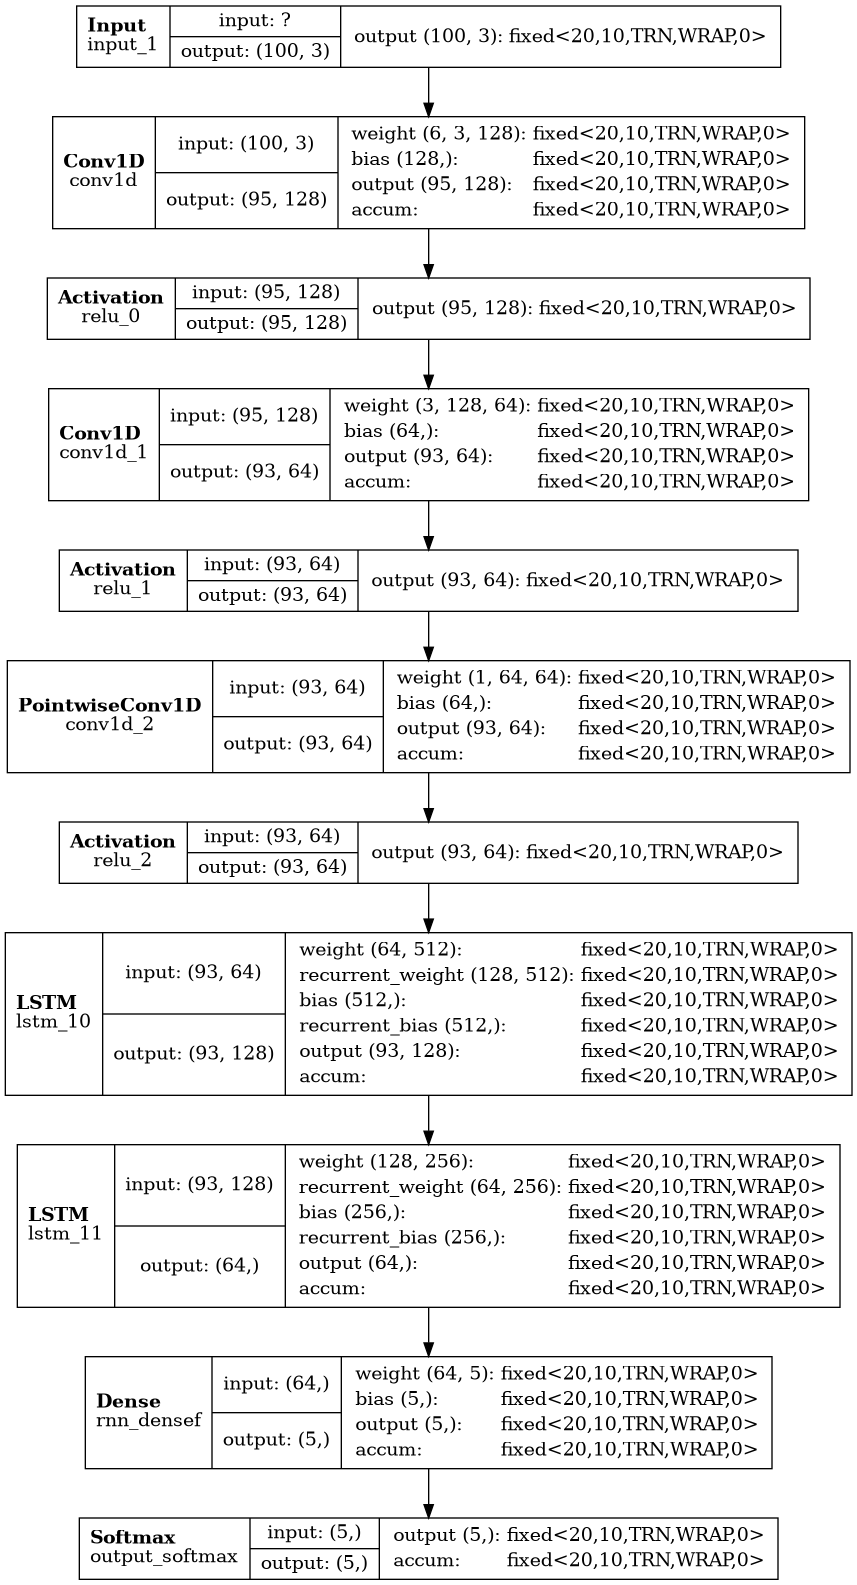

In [9]:
# create hls4ml model - higher precision (name)

config_name = hls4ml.utils.config_from_keras_model(model, granularity='model', default_precision='ap_fixed<20,10>')

# for layer in config_name['LayerName'].keys():
#     config_name['LayerName'][layer]['Trace'] = True
#     # implementation: list [latency,stable,argmax,legacy] (Default: stable)
#     config_name['LayerName']['output_softmax']['implementation'] = 'argmax'

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config_name)
print("-----------------------------------")
hls_model_name = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config_name, backend='Vivado', output_dir='model_1/hls4ml_lstm/name', part='xc7vx690tffg1761-2'
)

hls4ml.utils.plot_model(hls_model_name, show_shapes=True, show_precision=True, to_file=None)

In [ ]:
print("Compiling")
hls_model_name.compile()
print("Testing")
y_hls_name = hls_model_name.predict(X_testzero)

KeyboardInterrupt: 

In [ ]:
print("Comparing")
y_pred_name = np.argmax(y_hls_name, axis=1)
y_true = np.argmax(y_labhot, axis=1)

print("hls4ml name Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_hls_name, axis=1))))

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred_name, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

hls4ml name Accuracy: 0.94848
              precision    recall  f1-score   support

         ant       0.95      0.95      0.95      2500
         bee       0.93      0.95      0.94      2500
   butterfly       0.98      0.98      0.98      2500
    mosquito       0.89      0.89      0.89      2500
       snail       0.99      0.98      0.99      2500

    accuracy                           0.95     12500
   macro avg       0.95      0.95      0.95     12500
weighted avg       0.95      0.95      0.95     12500



In [ ]:
print(y_hls_name)
print(y_labhot)

print(y_pred_name)
print(y_true)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
[0 0 0 ... 4 4 4]
[0 0 0 ... 4 4 4]


In [ ]:
hls_model_name.build(csim=False)


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2019.1 (64-bit)
  **** SW Build 2552052 on Fri May 24 14:47:09 MDT 2019
  **** IP Build 2548770 on Fri May 24 18:01:18 MDT 2019
    ** Copyright 1986-2019 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2019.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2019.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'chanssen' on host 'hvm1' (Linux_x86_64 version 5.15.0-160-generic) on Wed Nov 12 22:35:14 PST 2025
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/chanssen/HLS4ML_VS_MANUAL/src/hdl/Quickdraw/keras/model_1/hls4ml_lstm/name'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/chanssen/HLS4ML_VS_MANUAL/src/hdl/Quickdraw/keras/model_1/hls4ml_lstm/name/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-10] Adding test 